# **The Gesture Showdown: A Rock-Paper-Scissors Adventure with YOLOv11**

![alt text](rock-paper-scissor-ft.jpg)

**In the heart of a bustling tech lab, where the hum of computers intertwined with the vibrant energy of creative minds, Ali—a passionate coder and lifelong gamer—dreamed of a project that would bridge the gap between classic gameplay and cutting-edge artificial intelligence. The idea was simple yet daring: to build a real-time rock-paper-scissors detection system that could "see" and understand hand gestures, transforming a game of chance into an interactive spectacle.**

**Ali’s inspiration stemmed from countless afternoons spent playing rock-paper-scissors with friends, marveling at how such a simple game could decide outcomes with a swift motion of the hand. But now, Alex envisioned a system where the computer would not only play but truly recognize the gestures as they happened. Determined to turn this idea into reality, Alex assembled a team of like-minded enthusiasts, each eager to explore the possibilities of computer vision.**

### **Chapter 1: Capturing the Essence of the Game**

**The first challenge was to capture the beauty and variety of human hand gestures. The team set up a high-definition webcam in their lab, turning the space into a mini recording studio. They recorded countless sessions under various lighting conditions and backgrounds, ensuring that every nuance of the gestures was captured. Each gesture had its unique signature:**
- A tightly clenched fist represented “`rock`.”
- An open hand, fingers spread gracefully, symbolized “`paper`.”
- A hand with the index and middle fingers extended in a precise V-shape signified “`scissors`.”

**Every frame was carefully recorded, with each gesture performed from multiple angles and distances, building a diverse and robust dataset.**

### **Chapter 2: The Art of Annotation**
**With thousands of images at their disposal, the next step was to teach the computer what each gesture looked like. The team turned to the meticulous process of annotation. Armed with popular tools like [CVAT](https://app.cvat.ai/), they painstakingly drew bounding boxes around the hands in each image, labeling them as “rock,” “paper,” or “scissors.” This step was crucial—each annotated image became a lesson for the machine, a hint to help it learn the subtleties of shape, orientation, and movement.**

**Alex often remarked, “Every box we draw is like giving the model a clue, a piece of the puzzle that will one day let it see the world as we do.”**

**They store the data and their annotations on a folder and publish it on [Roboflow]([dataset](https://universe.roboflow.com/roboflow-58fyf/rock-paper-scissors-sxsw)), so other researchers can access and build upon their work.**

**Download dataset from Roboflow**

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="UUWzD5rgyDcPheiuXg0O")
project = rf.workspace("roboflow-58fyf").project("rock-paper-scissors-sxsw")
version = project.version(14)
dataset = version.download("yolov11")
                

loading Roboflow workspace...
loading Roboflow project...


In [2]:
%pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


**Show data sample**

In [3]:
import cv2 
import random
import glob as glob 
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

In [4]:
def yolo2bbox(bbox ):
    xmin , ymin = bbox[0] - bbox[2]/2 , bbox[1] - bbox[3]/2
    xmax , ymax = bbox[0] + bbox[2]/2 , bbox[1] + bbox[3]/2
    return xmin , ymin , xmax , ymax

In [5]:
class_names = ['paper', 'rock', 'scissors']
colors = np.random.uniform(0, 255, size=(len(class_names), 3))

def draw_box(image , bbox , labels):
    w , h ,_ = image.shape 

    for box_num , box in enumerate(bbox):
        x1 , y1 , x2 , y2 = yolo2bbox(box)
        xmin , ymin , xmax , ymax = int(x1 * w) , int(y1 * h) , int(x2 * w) , int(y2 * h)
        width = xmax - xmin
        height = ymax - ymin 

        class_name = class_names[int(labels[box_num])]

        cv2.rectangle(image , 
                    (xmin , ymin),
                    (xmax , ymax),
                    color = colors[class_names.index(class_name)],
                    thickness = 2
                    )
        font_scale = min(1 , max(3,int(w/500)))
        font_thickness = min(1 , max(3,int(w/500)))

        p1 , p2  = (int(xmin) , int(ymin)) , (int(xmax), int(ymax))
        tw , th = cv2.getTextSize(class_name , 0 , fontScale= font_scale , thickness= font_thickness)[0]
        p2 = p1[0] +tw , p1[1] - th -10

        cv2.rectangle(image , p1 ,p2 , color = colors[class_names.index(class_name)] , thickness = -1)
        cv2.putText(image , 
                    class_name , 
                    (int(xmin)+1 , int(ymin -10)) ,
                    cv2.FONT_HERSHEY_SIMPLEX ,
                    font_scale ,
                    (255,255,255) ,
                    font_thickness
                    )
    return image

In [6]:
# Function to plot images with the bounding boxes.
def plot(image_paths, label_paths, num_samples):
    all_training_images = glob.glob(image_paths)
    all_training_labels = glob.glob(label_paths)
    all_training_images.sort()
    all_training_labels.sort()

    num_images = len(all_training_images)

    plt.figure(figsize=(15, 12))
    for i in range(num_samples):
        j = random.randint(0,num_images-1)
        image = cv2.imread(all_training_images[j])
        with open(all_training_labels[j], 'r') as f:
            bboxes = []
            labels = []
            label_lines = f.readlines()
            for label_line in label_lines:
                label = label_line[0]
                bbox_string = label_line[2:]#"0.22 .055 0.11 .19"
                x_c, y_c, w, h = bbox_string.split(' ')
                x_c = float(x_c)
                y_c = float(y_c)
                w = float(w)
                h = float(h)
                bboxes.append([x_c, y_c, w, h])
                labels.append(label)
        result_image = draw_box(image, bboxes, labels)
        plt.subplot(2, 2, i+1)
        plt.imshow(result_image[:, :, ::-1])
        plt.axis('off')
    plt.subplots_adjust(wspace=0)
    plt.tight_layout()
    plt.show()

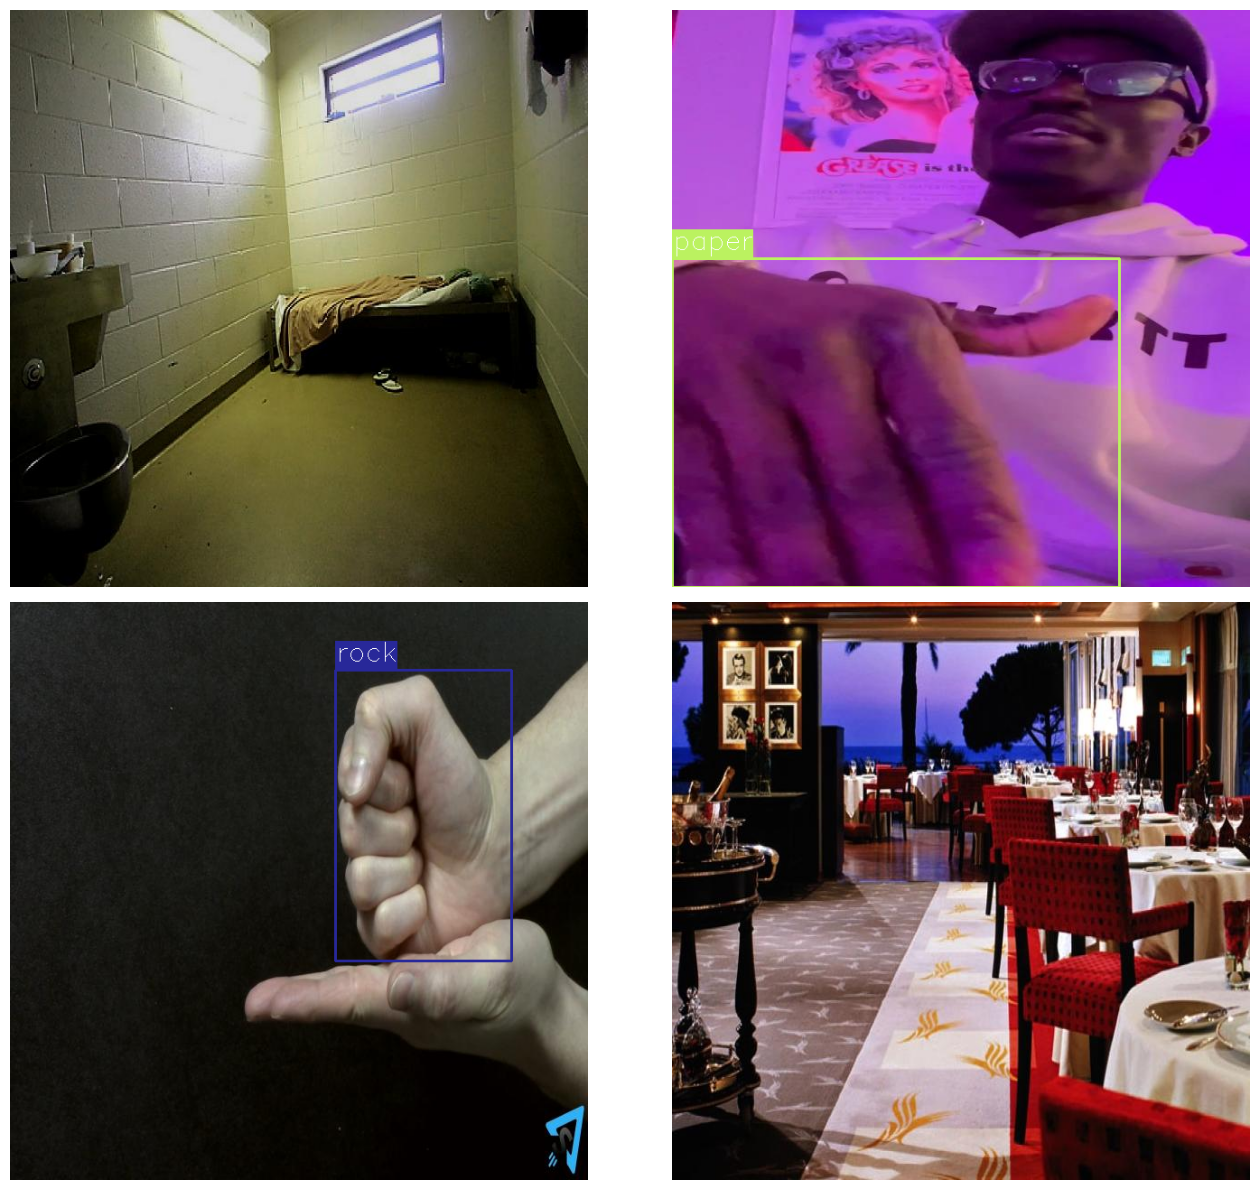

In [7]:
plot(image_paths='C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( YOLO11 )/rock-paper-scissors-14/train/images/*',
    label_paths='C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( YOLO11 )/rock-paper-scissors-14/train/labels/*',
    num_samples= 4,
)

### **Chapter 3: Training the Visionary**
**The stage was now set for the star of the project: YOLOv11, a state-of-the-art object detection model renowned for its speed and precision. The team configured the model to recognize the three classes and fine-tuned its parameters, adjusting anchor boxes and hyperparameters to best suit the size and form of the hand gestures.**

**Training began in earnest. For hours, the lab was filled with the rhythmic sound of data being processed, as the model learned to differentiate a clenched fist from an open hand, and an outstretched pair of fingers from any other gesture. With each epoch, the model’s predictions became sharper, more confident, and the loss decreased steadily—a silent testament to the progress being made.**

**At first install ultralytics to get YOLOv11 model**

```
pip install ultralytics
```

**Then load the model**

In [2]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11n model
model = YOLO("yolo11n.pt" )

**After that train the model for 100 epochs.**

In [3]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
Device Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [10]:
import torch
print(torch.cuda.is_available())

True


In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [12]:
# Use the model
results = model.train(data="C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( YOLO11 )/rock-paper-scissors-14/data.yaml", epochs=30 , device=0 ,workers=0, batch=8)  # train the model

Ultralytics 8.3.235  Python-3.12.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( YOLO11 )/rock-paper-scissors-14/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train11, nbs=64, nms=

2025/12/10 04:29:44 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



MLflow: logging run_id(3a7da9f350234fe794f646637f42ece1) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to C:\Users\ahmed\AI course FULL Curse ONLINE\Deep learning\Section13 computer vision ( YOLO11 )\runs\detect\train11
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/30      1.16G      1.369      3.474      1.542         13        640: 100% ━━━━━━━━━━━━ 807/807 4.6it/s 2:55<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 4.7it/s 7.7s0.3s
                   all        576        400      0.409      0.499      0.461      0.259

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      1.32G      1.482      2.427      1.605     

**Before publishing the model, we need to check the model's performance on the test set, so we predict an image and check the result**

### **Chapter 4: The Moment of Truth**
**After countless iterations and refinements, the day of real-time testing arrived. The lab was quiet, the tension palpable as the team connected a webcam to their custom-built detection pipeline. Live video feed streamed onto the monitor, and the moment of truth was at hand.**

**One by one, team members stepped forward. First, a colleague flashed a solid rock—a firm, clenched fist. The system sprang into action, quickly drawing a bounding box around the hand and labeling it “rock.” Next, another person presented an open hand. The model, now well-trained, identified it as “paper” with remarkable accuracy. Finally, the iconic scissors gesture appeared, the familiar V-shape captured flawlessly, and the system labeled it without hesitation.**

**Laughter and cheers erupted in the lab. The system was working in real time—detecting, classifying, and displaying the results with astonishing speed. The project had transcended its initial concept, evolving into a living, breathing demonstration of AI in action.**

In [28]:
def show_image(img , title = 'image'):
    rgp_img = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
    plt.imshow(rgp_img)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [2]:
import cv2
from ultralytics import YOLO

# Load the YOLO model with the best weights
model = YOLO('C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( YOLO11 )/runs/detect/train11/weights/best.pt')

# Initialize the camera
cap = cv2.VideoCapture(0)  # Use 0 for default laptop camera

if not cap.isOpened():
    print("Error: Could not open camera.")
    exit()

print("Starting camera feed...")

gesture_map = {0: 'Paper', 1: 'Rock', 2: 'Scissors'}

def determine_winner(g1, g2):
    if g1 == g2:
        return "Draw"
    if (g1 == 'Rock' and g2 == 'Scissors') or \
       (g1 == 'Scissors' and g2 == 'Paper') or \
       (g1 == 'Paper' and g2 == 'Rock'):
        return "Player 1 Wins"
    return "Player 2 Wins"

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Failed to capture image.")
        break

    frame = cv2.flip(frame, 1)
    results = model(frame, stream=True)

    player1_gesture = None
    player2_gesture = None

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            label = gesture_map.get(cls, 'Unknown')

            center_x = (x1 + x2) // 2
            mid = frame.shape[1] // 2

            if center_x < mid:
                player1_gesture = label
                cv2.putText(frame, f"Player 1: {label}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
            else:
                player2_gesture = label
                cv2.putText(frame, f"Player 2: {label}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,0,255), 2)

    if player1_gesture and player2_gesture:
        winner = determine_winner(player1_gesture, player2_gesture)
        cv2.putText(frame, winner, (50, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

    cv2.imshow("Rock Paper Scissors Detection", frame)

    cv2.waitKey(1) # 
    


    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Starting camera feed...

0: 480x640 (no detections), 13.5ms
Speed: 1.0ms preprocess, 13.5ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 14.5ms
Speed: 1.5ms preprocess, 14.5ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 19.4ms
Speed: 1.4ms preprocess, 19.4ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 8.3ms
Speed: 1.0ms preprocess, 8.3ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 7.7ms
Speed: 0.9ms preprocess, 7.7ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 8.3ms
Speed: 1.3ms preprocess, 8.3ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 9.3ms
Speed: 1.3ms preprocess, 9.3ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 16.9ms
Speed: 1.4ms prep

In [5]:
model = YOLO("C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( YOLO11 )/runs/detect/train11/weights/best.pt")


In [5]:
%pip install "numpy<2"

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
roboflow 1.2.11 requires opencv-python-headless==4.10.0.84, which is not installed.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.0.0 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.0 which is incompatible.


In [6]:
# Use the model
results = model.train(data="C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( YOLO11 )/rock-paper-scissors-14/data.yaml", epochs=20 , device=0 ,workers=0, batch=8)  # train the model

Ultralytics 8.3.235  Python-3.12.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( YOLO11 )/rock-paper-scissors-14/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( 

2025/12/10 13:30:23 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



MLflow: logging run_id(a7f0824044d14d1f945eda9919d774e9) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to C:\Users\ahmed\AI course FULL Curse ONLINE\Deep learning\Section13 computer vision ( YOLO11 )\runs\detect\train13
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/20      1.16G     0.8768     0.8045      1.165         13        640: 100% ━━━━━━━━━━━━ 807/807 4.9it/s 2:46<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 6.0it/s 6.0s0.2s
                   all        576        400      0.901      0.882      0.924      0.718

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      1.32G     0.9737     0.9372       1.22     

### **Chapter 5: Beyond the Game**
**The success of the real-time detection system was only the beginning. As the team celebrated their achievement, ideas for the future flowed freely. They envisioned applications far beyond a simple game:**
- Interactive Learning: Imagine educational tools that use gesture recognition to control digital content.
- Touchless Interfaces: Consider gesture-based controls for devices in environments where hygiene is paramount.
- Augmented Reality: Picture immersive games where your hand movements influence a virtual world.

**Ali’s eyes sparkled with the promise of new challenges and innovations. The rock-paper-scissors system had not only brought joy and excitement but had also opened up a gateway to endless possibilities in human-computer interaction.**

### **Epilogue: The Journey Continues**
**As the lab lights dimmed and the team gathered around to review their work, there was a shared sense of accomplishment. The journey—from capturing raw gestures to training a powerful AI model—had been both challenging and exhilarating. With YOLOv11 as their trusty ally, Alex and the team were poised to explore new frontiers in real-time detection and interactive technology.**

**The adventure was far from over. With every gesture detected and every challenge overcome, they were reminded that innovation is an ever-evolving journey—one that begins with a simple idea and grows into something truly extraordinary. And so, with hearts full of ambition and minds ready for the next breakthrough, they prepared for the adventures that lay ahead—one gesture, one frame, one discovery at a time.**

In [ ]:
import cv2
from ultralytics import YOLO

# Load the YOLO model with the best weights
model = YOLO('C:/Users/ahmed/AI course FULL Curse ONLINE/Deep learning/Section13 computer vision ( YOLO11 )/runs/detect/train13/weights/best.pt')

# Initialize the camera
cap = cv2.VideoCapture(0)  # Use 0 for default laptop camera

if not cap.isOpened():
    print("Error: Could not open camera.")
    exit()

print("Starting camera feed...")

gesture_map = {0: 'Paper', 1: 'Rock', 2: 'Scissors'}

def determine_winner(g1, g2):
    if g1 == g2:
        return "Draw"
    if (g1 == 'Rock' and g2 == 'Scissors') or \
       (g1 == 'Scissors' and g2 == 'Paper') or \
       (g1 == 'Paper' and g2 == 'Rock'):
        return "Player 1 Wins"
    return "Player 2 Wins"

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Failed to capture image.")
        break

    frame = cv2.flip(frame, 1)
    results = model(frame, stream=True)

    player1_gesture = None
    player2_gesture = None

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            label = gesture_map.get(cls, 'Unknown')

            center_x = (x1 + x2) // 2
            mid = frame.shape[1] // 2

            if center_x < mid:
                player1_gesture = label
                cv2.putText(frame, f"Player 1: {label}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
            else:
                player2_gesture = label
                cv2.putText(frame, f"Player 2: {label}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,0,255), 2)

    if player1_gesture and player2_gesture:
        winner = determine_winner(player1_gesture, player2_gesture)
        cv2.putText(frame, winner, (50, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

    cv2.imshow("Rock Paper Scissors Detection", frame)

    cv2.waitKey(1) # 
    


    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Starting camera feed...

0: 480x640 (no detections), 21.4ms
Speed: 2.0ms preprocess, 21.4ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 21.8ms
Speed: 1.9ms preprocess, 21.8ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 18.3ms
Speed: 2.0ms preprocess, 18.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 18.1ms
Speed: 2.0ms preprocess, 18.1ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 18.8ms
Speed: 1.9ms preprocess, 18.8ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 23.4ms
Speed: 1.9ms preprocess, 23.4ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 20.7ms
Speed: 1.9ms preprocess, 20.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 24.6ms
Speed: 1.